# Preparation


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import albumentations as A
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
import torchsummary


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
!pip install fvcore &> /dev/null
!pip install timm &> /dev/null
from timm.models.layers import DropPath

/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Dataset


In [ ]:
POLYP_DATA_PATH = '/content/drive/MyDrive/PolypSEG_PMT/polypData.npz'
PRETRAINED_PATH = '/content/drive/MyDrive/POLYPSEG_LT/pvt_v2_b2.pth'

In [ ]:
# Argumentation
train_transform = A.Compose([
        A.Resize(256, 256),
        A.ShiftScaleRotate(shift_limit=0.2, scale_limit=0.2, rotate_limit=30, p=0.5),
        A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])

val_transform = A.Compose([
        A.Resize(256, 256),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    ])


# Polyp Dataset
class PolypDS(Dataset):
    def __init__(self, data_path=POLYP_DATA_PATH, type=None, transform = None):
      super().__init__()

      data_np = np.load(data_path)
      self.images = data_np[f"{type}_img"]
      self.masks  = data_np[f"{type}_msk"].squeeze(-1)
      self.transform = transform

    def __getitem__(self, idx):
      img = self.images[idx]
      msk  = self.masks[idx]

      if self.transform is not None:
            transformed = self.transform(image=img, mask=msk)
            img = transformed["image"]
            msk = transformed["mask"]

      img = transforms.ToTensor()(img)
      msk = np.expand_dims(msk, axis = -1)
      msk = transforms.ToTensor()(msk)

      return img, msk

    def __len__(self):
      return len(self.images)

# Dataset
train_ds = PolypDS(type = 'train', transform=train_transform)
val_ds   = PolypDS(type = 'val', transform=val_transform)
test1_ds = PolypDS(type = 'test_kvasir', transform=val_transform)
test2_ds = PolypDS(type = 'test_etis', transform=val_transform)
test3_ds = PolypDS(type = 'test_cvc300', transform=val_transform)
test4_ds = PolypDS(type = 'test_clinic', transform=val_transform)
test5_ds = PolypDS(type = 'test_colon', transform=val_transform)


# DataLoader
trainloader = DataLoader(train_ds, batch_size=16, num_workers=2, shuffle=True)
valloader   = DataLoader(val_ds, batch_size=8, num_workers=2, shuffle=False)
testloader1 = DataLoader(test1_ds, batch_size=1, num_workers=2, shuffle=False)
testloader2 = DataLoader(test2_ds, batch_size=1, num_workers=2, shuffle=False)
testloader3 = DataLoader(test3_ds, batch_size=1, num_workers=2, shuffle=False)
testloader4 = DataLoader(test4_ds, batch_size=1, num_workers=2, shuffle=False)
testloader5 = DataLoader(test5_ds, batch_size=1, num_workers=2, shuffle=False)


/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Block


## PVTB2_pretrained

In [ ]:
from functools import partial

from timm.models.layers import DropPath, to_2tuple, trunc_normal_
from timm.models.registry import register_model
from timm.models.vision_transformer import _cfg
import math

class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0., linear=False):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
        self.linear = linear
        if self.linear:
            self.relu = nn.ReLU(inplace=True)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = self.fc1(x)
        if self.linear:
            x = self.relu(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None, attn_drop=0., proj_drop=0., sr_ratio=1, linear=False):
        super().__init__()
        assert dim % num_heads == 0, f"dim {dim} should be divided by num_heads {num_heads}."

        self.dim = dim
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.q = nn.Linear(dim, dim, bias=qkv_bias)
        self.kv = nn.Linear(dim, dim * 2, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        self.linear = linear
        self.sr_ratio = sr_ratio
        if not linear:
            if sr_ratio > 1:
                self.sr = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
                self.norm = nn.LayerNorm(dim)
        else:
            self.pool = nn.AdaptiveAvgPool2d(7)
            self.sr = nn.Conv2d(dim, dim, kernel_size=1, stride=1)
            self.norm = nn.LayerNorm(dim)
            self.act = nn.GELU()
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        q = self.q(x).reshape(B, N, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)

        if not self.linear:
            if self.sr_ratio > 1:
                x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
                x_ = self.sr(x_).reshape(B, C, -1).permute(0, 2, 1)
                x_ = self.norm(x_)
                kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
            else:
                kv = self.kv(x).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        else:
            x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
            x_ = self.sr(self.pool(x_)).reshape(B, C, -1).permute(0, 2, 1)
            x_ = self.norm(x_)
            x_ = self.act(x_)
            kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        k, v = kv[0], kv[1]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)

        return x

class Block(nn.Module):

    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, sr_ratio=1, linear=False):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(
            dim,
            num_heads=num_heads, qkv_bias=qkv_bias, qk_scale=qk_scale,
            attn_drop=attn_drop, proj_drop=drop, sr_ratio=sr_ratio, linear=linear)
        # NOTE: drop path for stochastic depth, we shall see if this is better than dropout here
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop, linear=linear)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = x + self.drop_path(self.attn(self.norm1(x), H, W))
        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))

        return x

class OverlapPatchEmbed(nn.Module):
    """ Image to Patch Embedding
    """

    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()

        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        assert max(patch_size) > stride, "Set larger patch_size than stride"

        self.img_size = img_size
        self.patch_size = patch_size
        self.H, self.W = img_size[0] // stride, img_size[1] // stride
        self.num_patches = self.H * self.W
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)

        return x, H, W


class PyramidVisionTransformerV2(nn.Module):
    def __init__(self, img_size=256, patch_size=16, in_chans=3, num_classes=1000, embed_dims=[64, 128, 256, 512],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4], qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm,
                 depths=[3, 4, 6, 3], sr_ratios=[8, 4, 2, 1], num_stages=4, linear=False):
        super().__init__()
        self.num_classes = num_classes
        self.depths = depths
        self.num_stages = num_stages

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]  # stochastic depth decay rule
        cur = 0

        for i in range(num_stages):
            patch_embed = OverlapPatchEmbed(img_size=img_size if i == 0 else img_size // (2 ** (i + 1)),
                                            patch_size=7 if i == 0 else 3,
                                            stride=4 if i == 0 else 2,
                                            in_chans=in_chans if i == 0 else embed_dims[i - 1],
                                            embed_dim=embed_dims[i])

            block = nn.ModuleList([Block(
                dim=embed_dims[i], num_heads=num_heads[i], mlp_ratio=mlp_ratios[i], qkv_bias=qkv_bias, qk_scale=qk_scale,
                drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[cur + j], norm_layer=norm_layer,
                sr_ratio=sr_ratios[i], linear=linear)
                for j in range(depths[i])])
            norm = norm_layer(embed_dims[i])
            cur += depths[i]

            setattr(self, f"patch_embed{i + 1}", patch_embed)
            setattr(self, f"block{i + 1}", block)
            setattr(self, f"norm{i + 1}", norm)

        # classification head
        self.head = nn.Linear(embed_dims[3], num_classes) if num_classes > 0 else nn.Identity()

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def freeze_patch_emb(self):
        self.patch_embed1.requires_grad = False

    @torch.jit.ignore
    def no_weight_decay(self):
        return {'pos_embed1', 'pos_embed2', 'pos_embed3', 'pos_embed4', 'cls_token'}  # has pos_embed may be better

    def get_classifier(self):
        return self.head

    def reset_classifier(self, num_classes, global_pool=''):
        self.num_classes = num_classes
        self.head = nn.Linear(self.embed_dim, num_classes) if num_classes > 0 else nn.Identity()

    def forward_features(self, x):
        B = x.shape[0]

        for i in range(self.num_stages):
            patch_embed = getattr(self, f"patch_embed{i + 1}")
            block = getattr(self, f"block{i + 1}")
            norm = getattr(self, f"norm{i + 1}")
            x, H, W = patch_embed(x)
            for blk in block:
                x = blk(x, H, W)
            x = norm(x)
            if i != self.num_stages - 1:
                x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

        return x.mean(dim=1)

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)

        return x


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super(DWConv, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)

        return x


def _conv_filter(state_dict, patch_size=16):
    """ convert patch embedding weight from manual patchify + linear proj to conv"""
    out_dict = {}
    for k, v in state_dict.items():
        if 'patch_embed.proj.weight' in k:
            v = v.reshape((v.shape[0], 3, patch_size, patch_size))
        out_dict[k] = v

    return out_dict

@register_model
def pvt_v2_b0(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[32, 64, 160, 256], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[2, 2, 2, 2], sr_ratios=[8, 4, 2, 1],
        **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b1(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[2, 2, 2, 2], sr_ratios=[8, 4, 2, 1],
        **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b2(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 4, 6, 3], sr_ratios=[8, 4, 2, 1], **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b3(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 4, 18, 3], sr_ratios=[8, 4, 2, 1],
        **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b4(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 8, 27, 3], sr_ratios=[8, 4, 2, 1],
        **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b5(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[4, 4, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 6, 40, 3], sr_ratios=[8, 4, 2, 1],
        **kwargs)
    model.default_cfg = _cfg()

    return model


@register_model
def pvt_v2_b2_li(pretrained=False, **kwargs):
    model = PyramidVisionTransformerV2(
        patch_size=4, embed_dims=[64, 128, 320, 512], num_heads=[1, 2, 5, 8], mlp_ratios=[8, 8, 4, 4], qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6), depths=[3, 4, 6, 3], sr_ratios=[8, 4, 2, 1], linear=True, **kwargs)
    model.default_cfg = _cfg()

    return model


/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
<ipython-input-7-0eb5016c1dca>:322: UserWarning: Overwriting pvt_v2_b0 in registry with __main__.pvt_v2_b0. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-7-0eb5016c1dca>:333: UserWarning: Overwriting pvt_v2_b1 in registry with __main__.pvt_v2_b1. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input-7-0eb5016c1dca>:344: UserWarning: Overwriting pvt_v2_b2 in registry with __main__.pvt_v2_b2. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
<ipython-input

In [ ]:
backbone = pvt_v2_b2()
backbone.load_state_dict(torch.load(PRETRAINED_PATH))

<All keys matched successfully>

In [ ]:
from fvcore.nn import FlopCountAnalysis, flop_count_table
model = backbone.cuda() # Move the model to GPU
model.eval()
input = torch.rand(size = (1,3,256,256)).cuda()
flops = FlopCountAnalysis(model, input)
print(flop_count_table(flops))

| module                      | #parameters or shape   | #flops     |
|:----------------------------|:-----------------------|:-----------|
| model                       | 25.363M                | 5.341G     |
|  patch_embed1               |  9.6K                  |  39.846M   |
|   patch_embed1.proj         |   9.472K               |   38.535M  |
|    patch_embed1.proj.weight |    (64, 3, 7, 7)       |            |
|    patch_embed1.proj.bias   |    (64,)               |            |
|   patch_embed1.norm         |   0.128K               |   1.311M   |
|    patch_embed1.norm.weight |    (64,)               |            |
|    patch_embed1.norm.bias   |    (64,)               |            |
|  block1                     |  1.051M                |  1.123G    |
|   block1.0                  |   0.35M                |   0.374G   |
|    block1.0.norm1           |    0.128K              |    1.311M  |
|    block1.0.attn            |    0.279M              |    84.431M |
|    block1.0.norm2 

## CH-layer (original)

In [ ]:
class ChLayer(nn.Module):
  def __init__(self,in_channels):
    super(ChLayer,self).__init__()
    self.conv1x1 = nn.Conv2d(in_channels,in_channels,kernel_size = 1, padding = 'same')
    self.BN = nn.BatchNorm2d(in_channels)
    self.relu = nn.ReLU()
    self.AAP = nn.AdaptiveAvgPool2d(1)
    self.cwc_down = nn.Conv2d(in_channels,in_channels//8, kernel_size=1, stride=1, padding=0)
    self.cwc_up = nn.Conv2d(in_channels//8,in_channels,kernel_size = 1,stride = 1, padding =0)
    self.sigmoid = nn.Sigmoid()
  def forward(self,x):
    x = self.conv1x1(x)
    x = self.BN(x)
    x = self.relu(x)
    x1 = x
    x = self.AAP(x)
    x = self.cwc_down(x)
    x = self.relu(x)
    x = self.cwc_up(x)
    x = self.sigmoid(x)
    x = x*x1
    return x

In [ ]:
from fvcore.nn import FlopCountAnalysis, flop_count_table
model = ChLayer(512).cuda() # Move the model to GPU
model.eval()
input = torch.rand(size = (1,512,8,8)).cuda()
flops = FlopCountAnalysis(model, input)
print(flop_count_table(flops))

| module            | #parameters or shape   | #flops   |
|:------------------|:-----------------------|:---------|
| model             | 0.33M                  | 0.164M   |
|  conv1x1          |  0.263M                |  0       |
|   conv1x1.weight  |   (512, 512, 1, 1)     |          |
|   conv1x1.bias    |   (512,)               |          |
|  BN               |  1.024K                |  65.536K |
|   BN.weight       |   (512,)               |          |
|   BN.bias         |   (512,)               |          |
|  cwc_down         |  32.832K               |  32.768K |
|   cwc_down.weight |   (64, 512, 1, 1)      |          |
|   cwc_down.bias   |   (64,)                |          |
|  cwc_up           |  33.28K                |  32.768K |
|   cwc_up.weight   |   (512, 64, 1, 1)      |          |
|   cwc_up.bias     |   (512,)               |          |
|  AAP              |                        |  32.768K |


## CBAM

In [ ]:
class BasicConv(nn.Module):
    def __init__(self, in_planes, out_planes, kernel_size, stride=1, padding=0, dilation=1, groups=1, relu=True, bn=True, bias=False):
        super(BasicConv, self).__init__()
        self.out_channels = out_planes
        self.conv = nn.Conv2d(in_planes, out_planes, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=bias)
        self.bn = nn.BatchNorm2d(out_planes,eps=1e-5, momentum=0.01, affine=True) if bn else None
        self.relu = nn.GELU() if relu else None

    def forward(self, x):
        x = self.conv(x)
        if self.bn is not None:
            x = self.bn(x)
        if self.relu is not None:
            x = self.relu(x)
        return x

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16, pool_types=['avg', 'max']):
        super(ChannelGate, self).__init__()
        self.gate_channels = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
        self.pool_types = pool_types
    def forward(self, x):
        channel_att_sum = None
        for pool_type in self.pool_types:
            if pool_type=='avg':
                avg_pool = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
                channel_att_raw = self.mlp( avg_pool )
            elif pool_type=='max':
                max_pool = F.max_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
                channel_att_raw = self.mlp( max_pool )
            elif pool_type=='lp':
                lp_pool = F.lp_pool2d( x, 2, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
                channel_att_raw = self.mlp( lp_pool )
            elif pool_type=='lse':
                # LSE pool only
                lse_pool = logsumexp_2d(x)
                channel_att_raw = self.mlp( lse_pool )

            if channel_att_sum is None:
                channel_att_sum = channel_att_raw
            else:
                channel_att_sum = channel_att_sum + channel_att_raw

        scale = F.sigmoid( channel_att_sum ).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

def logsumexp_2d(tensor):
    tensor_flatten = tensor.view(tensor.size(0), tensor.size(1), -1)
    s, _ = torch.max(tensor_flatten, dim=2, keepdim=True)
    outputs = s + (tensor_flatten - s).exp().sum(dim=2, keepdim=True).log()
    return outputs

class ChannelPool(nn.Module):
    def forward(self, x):
        return torch.cat( (torch.max(x,1)[0].unsqueeze(1), torch.mean(x,1).unsqueeze(1)), dim=1 )

class SpatialGate(nn.Module):
    def __init__(self):
        super(SpatialGate, self).__init__()
        kernel_size = 7
        self.compress = ChannelPool()
        self.spatial = BasicConv(2, 1, kernel_size, stride=1, padding=(kernel_size-1) // 2, relu=False)
    def forward(self, x):
        x_compress = self.compress(x)
        x_out = self.spatial(x_compress)
        scale = F.sigmoid(x_out) # broadcasting
        return x * scale

class CBAM(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16, pool_types=['avg', 'max'], no_spatial=False):
        super(CBAM, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio, pool_types)
        self.no_spatial=no_spatial
        if not no_spatial:
            self.SpatialGate = SpatialGate()
    def forward(self, x):
        x_out = self.ChannelGate(x)
        if not self.no_spatial:
            x_out = self.SpatialGate(x_out)
        return x_out

## BFEB

In [ ]:
class BFEB(nn.Module):
    def __init__(self):
        super(BFEB, self).__init__()
        self.sigmoid = nn.Sigmoid()

    def forward(self, feature_map, pred):
        """
        feature_map: Tensor đầu vào chứa thông tin đặc trưng (B, C, H, W)
        pred: Tensor dự đoán trước khi qua sigmoid (B, 1, H, W)
        """
        pred = self.sigmoid(pred)  # Chuẩn hóa giá trị dự đoán về [0, 1]

        # Tính toán B_Att (Boundary Attention)
        B_Att = 1 - torch.abs(pred - 0.5) / 0.5

        # Tính toán F_Att (Foreground Attention)
        F_Att = torch.abs(0.5 - pred) - B_Att

        Fi = F_Att - 0.5 * B_Att
        out = feature_map * Fi
        output = out + feature_map

        return output


## CBR

In [ ]:
class CBR(nn.Module):
  def __init__(self,in_channels,out_channels):
    super(CBR,self).__init__()
    self.BN = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()
    self.conv = nn.Conv2d(in_channels,out_channels,kernel_size = 1, padding = 'same')
  def forward(self,x):
    x = self.conv(x)
    x = self.BN(x)
    x = self.relu(x)
    return x

## GAB(Group Aggregation Bridge module)

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape, )

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

class GAB(nn.Module):
    def __init__(self, dim_xh, dim_xl, k_size=3, d_list=[1, 2, 3 , 4 ,5 , 6]):
        super().__init__()
        self.pre_project = nn.Conv2d(dim_xh, dim_xl, 1)
        group_size = dim_xl

        # Group 1: Multi-scale dilated convolution
        self.g1_1 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[0], groups=group_size+1)
        )
        self.g1_2 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[2], groups=group_size+1)
        )
        self.g1_3 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[4], groups=group_size+1)
        )

        # Group 2: Multi-scale dilated convolution

        self.g2_1 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[1], groups=group_size+1)
        )
        self.g2_2 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[3], groups=group_size+1)
        )
        self.g2_3 = nn.Sequential(
            LayerNorm(normalized_shape=group_size+1, data_format='channels_first'),
            nn.Conv2d(group_size + 1, group_size + 1, kernel_size=3, stride=1,
                      padding='same',
                      dilation=d_list[5], groups=group_size+1)
        )

        self.tail_conv = nn.Sequential(
            LayerNorm(normalized_shape=dim_xl * 2 + 2, data_format='channels_first'),
            nn.Conv2d(dim_xl * 2 + 2, dim_xl, 1)
        )
        self.conv_out = nn.Conv2d(dim_xl*3+3,dim_xl+1,kernel_size = 1, padding = 'same')

    def forward(self, xh, xl, mask):
        xh = self.pre_project(xh)
        xh = F.interpolate(xh, size=[xl.size(2), xl.size(3)], mode='bilinear', align_corners=True)

        # Chia thành 2 nhóm
        xh= torch.chunk(xh, 2, dim=1)
        xl= torch.chunk(xl, 2, dim=1)

        # Nhóm 1:
        x1_1 = self.g1_1(torch.cat((xh[0], xl[0], mask), dim=1))
        x1_2 = self.g1_2(torch.cat((xh[0], xl[0], mask), dim=1))
        x1_3 = self.g1_3(torch.cat((xh[0], xl[0], mask), dim=1))
        x1 = self.conv_out(torch.cat((x1_1, x1_2, x1_3), dim=1))

        # Nhóm 2:

        x2_1 = self.g1_1(torch.cat((xh[1], xl[1], mask), dim=1))
        x2_2 = self.g1_2(torch.cat((xh[1], xl[1], mask), dim=1))
        x2_3 = self.g1_3(torch.cat((xh[1], xl[1], mask), dim=1))
        x2 = self.conv_out(torch.cat((x2_1, x2_2, x2_3), dim=1))


        # Gộp kết quả của cả hai nhóm
        x = torch.cat((x1, x2), dim=1)
        x = self.tail_conv(x)
        return x


##The proposed decoder

In [ ]:
class up_conv(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(up_conv,self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(ch_in,ch_out,kernel_size=3,stride=1,padding="same",bias=False,),
		    nn.BatchNorm2d(ch_out),
			nn.ReLU(inplace=True),
        )

    def forward(self,x):
        x = self.up(x)
        return x
class Decoder(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.up = up_conv(in_channels,out_channels)
    self.sigmoid = nn.Sigmoid()
    self.conv11 = nn.Conv2d(out_channels,1,kernel_size = 1,padding = 'same')
  def forward(self,x):
    x = self.up(x)
    decoder = x
    x = self.conv11(x)
    pred = self.sigmoid(x)
        # Tính toán B_Att (Boundary Attention)
    B_Att = 1 - torch.abs(pred - 0.5) / 0.5
        # Tính toán F_Att (Foreground Attention)
    F_Att = torch.abs(0.5 - pred) - B_Att
    Fi = F_Att - 0.5 * B_Att
    return decoder,Fi

In [ ]:
from fvcore.nn import FlopCountAnalysis, flop_count_table
model = Decoder(512,320).cuda() # Move the model to GPU
model.eval()
input = torch.rand(size = (1,512,8,8)).cuda()
flops = FlopCountAnalysis(model, input)
print(flop_count_table(flops))

| module            | #parameters or shape   | #flops   |
|:------------------|:-----------------------|:---------|
| model             | 1.476M                 | 0.295M   |
|  up.up            |  1.475M                |  0.295M  |
|   up.up.1         |   1.475M               |   0      |
|    up.up.1.weight |    (320, 512, 3, 3)    |          |
|   up.up.2         |   0.64K                |   0.164M |
|    up.up.2.weight |    (320,)              |          |
|    up.up.2.bias   |    (320,)              |          |
|   up.up.0         |                        |   0.131M |
|  conv11           |  0.321K                |  0       |
|   conv11.weight   |   (1, 320, 1, 1)       |          |
|   conv11.bias     |   (1,)                 |          |


##PASPP

In [ ]:
class PASPP(nn.Module):
    def __init__(self, inplanes, outplanes, output_stride=4, BatchNorm=nn.BatchNorm2d):
        super().__init__()
        if output_stride == 4:
            dilations = [1, 6, 12, 18]
        elif output_stride == 8:
            dilations = [1, 4, 6, 10]
        elif output_stride == 2:
            dilations = [1, 12, 24, 36]
        elif output_stride == 16:
            dilations = [1, 2, 3, 4]
        elif output_stride == 1:
            dilations = [1, 16, 32, 48]
        else:
            raise NotImplementedError
        self._norm_layer = BatchNorm
        self.silu = nn.SiLU(inplace=True)
        self.conv1 = self._make_layer(inplanes, inplanes // 4)
        self.conv2 = self._make_layer(inplanes, inplanes // 4)
        self.conv3 = self._make_layer(inplanes, inplanes // 4)
        self.conv4 = self._make_layer(inplanes, inplanes // 4)
        self.atrous_conv1 = nn.Conv2d(inplanes // 4, inplanes // 4, kernel_size=3, dilation=dilations[0], padding=dilations[0])
        self.atrous_conv2 = nn.Conv2d(inplanes // 4, inplanes // 4, kernel_size=3, dilation=dilations[1], padding=dilations[1])
        self.atrous_conv3 = nn.Conv2d(inplanes // 4, inplanes // 4, kernel_size=3, dilation=dilations[2], padding=dilations[2])
        self.atrous_conv4 = nn.Conv2d(inplanes // 4, inplanes // 4, kernel_size=3, dilation=dilations[3], padding=dilations[3])
        self.conv5 = self._make_layer(inplanes // 2, inplanes // 2)
        self.conv6 = self._make_layer(inplanes // 2, inplanes // 2)
        self.convout = self._make_layer(inplanes, inplanes)

    def _make_layer(self, inplanes, outplanes):
        layer = []
        layer.append(nn.Conv2d(inplanes, outplanes, kernel_size = 1))
        layer.append(self._norm_layer(outplanes))
        layer.append(self.silu)
        return nn.Sequential(*layer)

    def forward(self, X):
        x1 = self.conv1(X)
        x2 = self.conv2(X)
        x3 = self.conv3(X)
        x4 = self.conv4(X)

        x12 = torch.add(x1, x2)
        x34 = torch.add(x3, x4)

        x1 = torch.add(self.atrous_conv1(x1),x12)
        x2 = torch.add(self.atrous_conv2(x2),x12)
        x3 = torch.add(self.atrous_conv3(x3),x34)
        x4 = torch.add(self.atrous_conv4(x4),x34)

        x12 = torch.cat([x1, x2], dim = 1)
        x34 = torch.cat([x3, x4], dim = 1)

        x12 = self.conv5(x12)
        x34 = self.conv5(x34)
        x = torch.cat([x12, x34], dim=1)
        x = self.convout(x)
        return x

# Model


In [ ]:
class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn


    def forward(self, x):
        return self.fn(x) + x
class PCRN(nn.Module):
  def __init__(self,backbone,channel_index = [64, 128, 320, 512]):
    super(PCRN,self).__init__()
    '''Parent Encoder'''
    self.backbone = torch.nn.Sequential(*list(backbone.children()))[:-1]
    for i in [1, 4, 7, 10]:
        self.backbone[i] = torch.nn.Sequential(*list(self.backbone[i].children()))


    '''Children Encoder'''
    self.ChLayer1 = ChLayer(channel_index[0])
    self.ChLayer2 = ChLayer(channel_index[1])
    self.ChLayer3 = ChLayer(channel_index[2])
    self.ChLayer4 = ChLayer(channel_index[3])
    # self.ChLayer5 = ChLayer(channel_index[4])
    self.conv1 = nn.Conv2d(channel_index[0],channel_index[1],kernel_size = 1, padding = 'same')
    self.conv2 = nn.Conv2d(channel_index[1],channel_index[2],kernel_size = 1, padding = 'same')
    self.conv3 = nn.Conv2d(channel_index[2],channel_index[3],kernel_size = 1, padding = 'same')
    # self.conv4 = nn.Conv2d(channel_index[3],channel_index[4],kernel_size = 1, padding = 'same')
    self.MP= nn.MaxPool2d(kernel_size = 2, stride = 2)


    '''Attention'''
    self.GAB1 = GAB(channel_index[1],channel_index[0])
    self.GAB2 = GAB(channel_index[2],channel_index[1])
    self.GAB3 = GAB(channel_index[3],channel_index[2])
    # self.GAB4 = GAB(channel_index[4],channel_index[3])

    '''Decoder Module'''

    self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

    self.decoder3 = Decoder(channel_index[3],channel_index[2])
    self.decoder2 = Decoder(channel_index[2],channel_index[1])
    self.decoder1 = Decoder(channel_index[1],channel_index[0])


    # self.BFEB = BFEB()
    self.conv_out = nn.Conv2d(channel_index[0],1,kernel_size = 1,padding = 'same')
    self.up_out = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=False)
    self.sigmoid = nn.Sigmoid()

    '''Bottleneck'''
    # self.b5 = nn.Sequential(
    #             Residual(nn.Sequential(
    #                 #PCA
    #                 PCA(channel_index[3], 64),
    #                 # nn.Conv2d(dim, dim, kernel_size = 9, groups=dim, padding="same"),
    #                 nn.GELU(),
    #                 nn.BatchNorm2d(channel_index[3])
    #             )),
    #             # nn.Conv2d(dim, dim, kernel_size=1),
    #             #PSA
    #             PSA(channel_index[3], 64),
    #             nn.GELU(),
    #             nn.BatchNorm2d(channel_index[3]))
    self.b5 = PASPP(channel_index[3],channel_index[3])

  def get_pyramid(self,x):
      pyramid = []
      B = x.shape[0]
      for i, module in enumerate(self.backbone):
          if i in [0, 3, 6, 9]:
              x, H, W = module(x)
          elif i in [1, 4, 7,10]:
              for sub_module in module:
                  x = sub_module(x, H, W)
          else:
              x = module(x)
              x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
              pyramid.append(x)
      return pyramid

  def forward(self,x):

    '''Parent Encoder'''
    # model = self.backbone
    # endpoints = model.extract_endpoints(x)
    # p5 = endpoints['reduction_5'] #([1, 448, 8, 8])
    # p4 = endpoints['reduction_4'] #([1,160,16,16])
    # p3 = endpoints['reduction_3'] #([1,56,32,32])
    # p2 = endpoints['reduction_2'] #([1,32,64,64])
    # p1 = endpoints['reduction_1'] #([1, 24, 128, 128])

    pyramid=self.get_pyramid(x)
    p4 = pyramid[3]
    p3 = pyramid[2]
    p2 = pyramid[1]
    p1 = pyramid[0]


    '''Children Encoder '''
    c1 = self.ChLayer1(p1) #(1,24,128,128)
    d1 = c1
    c1 = self.conv1(self.MP(c1)) #(1,32,64,64)
    c1 = c1+p2
    c2 = self.ChLayer2(c1) #(1,32,64,64)
    d2 = c2
    c2 = self.conv2(self.MP(c2)) #(1,56,32,32)
    c2 = c2+p3
    c3 = self.ChLayer3(c2) #(1,56,32,32)
    d3 = c3
    c3 = self.conv3(self.MP(c3)) #(1,160,16,16)
    c3 = c3+p4
    c4 = self.ChLayer4(c3) #(1,160,16,16)
    d4 = c4
    # c4 = self.conv4(self.MP(c4)) #(1,448,8,8)
    # c4 = c4+p5
    # c5 = self.ChLayer5(c4) #(1,448,8,8)
    # d5 = c5

    '''Decoder Module'''



    de4,mask4 = self.decoder3(self.b5(d4)) #([1,1,32,32])
    bfeb3 = self.GAB3(self.up(d4),d3,mask4) #([1, 56, 32, 32])
    # bfeb3_decoder = self.conv12(bfeb3) #([1, 1, 32, 32])
    decoder3 = bfeb3 + de4 #([1, 1, 32, 32])
    # decoder3 = self.conv12(decoder3)

    de3,mask3 = self.decoder2(decoder3) #([1,1,64,64])
    bfeb2 = self.GAB2(self.up(bfeb3),d2,mask3) #([1, 32, 64, 64])
    # bfeb2_decoder = self.conv13(bfeb2)
    decoder2 = bfeb2 + de3 #([1, 1, 64, 64])
    # decoder2 = self.conv13(decoder2)

    de2, mask2 = self.decoder1(decoder2)
    bfeb1 = self.GAB1(self.up(bfeb2),d1,mask2)
    # bfeb1_decoder = self.conv14(bfeb1)
    decoder1 = bfeb1 + de2 #([1, 1, 128, 128])
    # decoder1 = self.conv14(decoder1)


    out = self.conv_out(self.up_out(decoder1))
    out = self.sigmoid(out)

    return out

backbone = pvt_v2_b2()
backbone.load_state_dict(torch.load(PRETRAINED_PATH))

model = PCRN(backbone=backbone)

In [ ]:
# from fvcore.nn import FlopCountAnalysis, flop_count_table
# model = model.cuda() # Move the model to GPU
# model.eval()
# input = torch.rand(size = (1,3,256,256)).cuda()
# flops = FlopCountAnalysis(model, input)
# print(flop_count_table(flops))

| module                      | #parameters or shape   | #flops     |
|:----------------------------|:-----------------------|:-----------|
| model                       | 29.59M                 | 5.685G     |
|  backbone                   |  24.85M                |  5.341G    |
|   backbone.0                |   9.6K                 |   39.846M  |
|    backbone.0.proj          |    9.472K              |    38.535M |
|    backbone.0.norm          |    0.128K              |    1.311M  |
|   backbone.1                |   1.051M               |   1.123G   |
|    backbone.1.0             |    0.35M               |    0.374G  |
|    backbone.1.1             |    0.35M               |    0.374G  |
|    backbone.1.2             |    0.35M               |    0.374G  |
|   backbone.2                |   0.128K               |   1.311M   |
|    backbone.2.weight        |    (64,)               |            |
|    backbone.2.bias          |    (64,)               |            |
|   backbone.3      

# Metrics

In [ ]:
def iou_score_fn(output, target):
    smooth = 1e-5

    # if torch.is_tensor(output):
    #    output = torch.sigmoid(output).data.cpu().numpy()
    # if torch.is_tensor(target):
    #    target = target.data.cpu().numpy()

    output = output.data.cpu().numpy()
    target = target.data.cpu().numpy()

    output_ = output > 0.5
    target_ = target > 0.5
    intersection = (output_ & target_).sum()
    union = (output_ | target_).sum()

    return (intersection + smooth) / (union + smooth)

def dice_coef_fn(output, target):
    smooth = 1

    output = output.view(-1)
    target = target.view(-1)
    intersection = (output * target).sum()

    return (2. * intersection + smooth) / (output.sum() + target.sum() + smooth)

class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)

        return 1 - dice

dice_loss = DiceLoss()
def calc_loss(pred, target, bce_weight=0.5):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    dice =  dice_loss(pred, target)
    loss = bce * bce_weight + dice * (1 - bce_weight)

    return loss

In [ ]:
class BCELoss(nn.Module):
    def __init__(self):
        super(BCELoss, self).__init__()
        self.bceloss = nn.BCELoss()

    def forward(self, pred, target):
        size = pred.size(0)
        pred_ = pred.view(size, -1)
        target_ = target.view(size, -1)

        return self.bceloss(pred_, target_)


class BceDiceLoss(nn.Module):
    def __init__(self, wb, wd):
        super(BceDiceLoss, self).__init__()
        self.bce = BCELoss()
        self.dice = DiceLoss()
        self.wb = wb
        self.wd = wd

    def forward(self, pred, target):
        bceloss = self.bce(pred, target)
        diceloss = self.dice(pred, target)

        loss = self.wd * diceloss + self.wb * bceloss
        return loss

class GT_BceDiceLoss(nn.Module):
    def __init__(self, wb=0.5, wd=0.5):
        super(GT_BceDiceLoss, self).__init__()
        self.bcedice = BceDiceLoss(wb, wd)

    def forward(self, gt_pre, out, target):
        bcediceloss = self.bcedice(out, target)
        gt_pre5, gt_pre4, gt_pre3, gt_pre2, gt_pre1 = gt_pre
        gt_loss = self.bcedice(gt_pre5, target) * 0.1 + self.bcedice(gt_pre4, target) * 0.2 + self.bcedice(gt_pre3, target) * 0.3 + self.bcedice(gt_pre2, target) * 0.4 + self.bcedice(gt_pre1, target) * 0.5
        return bcediceloss + gt_loss


In [ ]:
class DiceLoss(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_true):
        dice = dice_coef_fn(y_pred, y_true)

        return 1 - dice
def tversky(y_true, y_pred, smooth = 1e-5):
    # y_pred = torch.sigmoid(y_pred)

    y_true_pos = y_true.view(-1)
    y_pred_pos = y_pred.view(-1)
    true_pos = torch.sum(y_true_pos * y_pred_pos)
    false_neg = torch.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = torch.sum((1 - y_true_pos) * y_pred_pos)
    alpha = 0.7
    return (true_pos + smooth) / (true_pos + alpha * false_neg + (1 - alpha) * false_pos + smooth)
def tversky_loss(y_true, y_pred):
    return 1 - tversky(y_true, y_pred)
def dice_tversky_loss(pred,target, bce_weight = 0.5):
    dice = DiceLoss()(pred, target)
    tv = tversky_loss(target, pred)

    loss = dice * bce_weight + tv * (1 - bce_weight)

    return loss

# Train

In [ ]:
!pip install pytorch-lightning &> /dev/null
import pytorch_lightning as pl

class Segmentor(pl.LightningModule):
    def __init__(self, model = model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

    def get_metrics(self):
        # don't show the version number
        items = super().get_metrics()
        items.pop("v_num", None)
        return items

    def _step(self, batch):
        image, y_true = batch
        y_pred = self.model(image)
        loss = dice_tversky_loss(y_true.float(), y_pred)
        dice_score = dice_coef_fn(y_pred, y_true)
        iou_score = iou_score_fn(y_pred, y_true)
        return loss, dice_score, iou_score

    def training_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"loss": loss, "train_dice": dice_score, "train_iou": iou_score}
        self.log_dict(metrics, on_step=False, on_epoch=True, prog_bar = True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"val_loss": loss, "val_dice": dice_score, "val_iou": iou_score}
        self.log_dict(metrics, prog_bar = True)
        return metrics

    def test_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"loss":loss, "test_dice": dice_score, "test_iou": iou_score}
        self.log_dict(metrics, prog_bar = True)
        return metrics


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                         factor = 0.5, patience=10, verbose =True)
        lr_schedulers = {"scheduler": scheduler, "monitor": "val_dice"}
        return [optimizer], lr_schedulers


In [ ]:
import csv
class HistoryLogger(pl.callbacks.Callback):
    def __init__(self, dir = "history_rivf.csv"):
        self.dir = dir
    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        if "loss_epoch" in metrics.keys():
            logs = {"epoch": trainer.current_epoch}
            keys = ["loss_epoch", "train_dice_epoch", "val_loss","val_dice"
                    ]
            for key in keys:
                logs[key] = metrics[key].item()
            header = list(logs.keys())
            isFile = os.path.isfile(self.dir)
            with open(self.dir, 'a', newline='') as csvfile:
                writer = csv.DictWriter(csvfile, fieldnames=header)
                if not isFile:
                    writer.writeheader()
                writer.writerow(logs)
        else:
            pass

In [ ]:
import os

In [ ]:
ckpt_root = '/content/drive/MyDrive/CV_course/PolypSeg/Lam/ckpt_Polyp/ckpt0.9346.ckpt'

In [ ]:
model = model.train()
os.makedirs('/content/drive/MyDrive/CV_course/PolypSeg/Lam/ckpt_Polyp', exist_ok = True)
check_point = pl.callbacks.model_checkpoint.ModelCheckpoint("/content/drive/MyDrive/CV_course/PolypSeg/Lam/ckpt_Polyp", filename="ckpt{val_dice:0.4f}",
                                                            monitor="val_dice", mode = "max", save_top_k =1,
                                                            verbose=True, save_weights_only=True,
                                                            auto_insert_metric_name=False,)
progress_bar = pl.callbacks.TQDMProgressBar()
logger = HistoryLogger()
PARAMS = {"benchmark": True, "enable_progress_bar" : True,"logger":False,
        #   "callbacks" : [progress_bar],
        #    "overfit_batches" :1,
          "callbacks" : [check_point, progress_bar],
          "log_every_n_steps" :1, "num_sanity_val_steps":0, "max_epochs":150,
          "precision":16,
          }


trainer = pl.Trainer(**PARAMS)

# Uncomment to load the best model
segmentor = Segmentor(model=model)
# Uncomment to train model
# segmentor = Segmentor(model=model)
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.fit(segmentor, trainloader, valloader)

/usr/local/lib/python3.11/dist-packages/lightning_fabric/connector.py:571: `precision=16` is supported for historical reasons but its usage is discouraged. Please set your precision to 16-mixed instead!
INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:654: Checkpoint directory /content/drive/MyDrive/CV_course/PolypSeg/Lam/ckpt_Polyp exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type | Params | Mode 
---------------------------------------
0 | model | PCRN | 29.6 M | train
------------------------------

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Epoch 0, global step 91: 'val_dice' reached 0.89377 (best 0.89377), saving model to '/content/drive/MyDrive/CV_course/PolypSeg/Lam/ckpt_Polyp/ckpt0.8938.ckpt' as top 1
INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

# Test

In [ ]:
!pip install pytorch-lightning &> /dev/null
import pytorch_lightning as pl

class Segmentor(pl.LightningModule):
    def __init__(self, model = model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

    def get_metrics(self):
        # don't show the version number
        items = super().get_metrics()
        items.pop("v_num", None)
        return items

    def _step(self, batch):
        image, y_true = batch
        y_pred = self.model(image)
        loss = dice_tversky_loss(y_true.float(), y_pred)
        dice_score = dice_coef_fn(y_pred, y_true)
        iou_score = iou_score_fn(y_pred, y_true)
        return loss, dice_score, iou_score

    def training_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"loss": loss, "train_dice": dice_score, "train_iou": iou_score}
        self.log_dict(metrics, on_step=False, on_epoch=True, prog_bar = True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"val_loss": loss, "val_dice": dice_score, "val_iou": iou_score}
        self.log_dict(metrics, prog_bar = True)
        return metrics

    def test_step(self, batch, batch_idx):
        loss, dice_score, iou_score = self._step(batch)
        metrics = {"loss":loss, "test_dice": dice_score, "test_iou": iou_score}
        self.log_dict(metrics, prog_bar = True)
        return metrics


    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-4)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max",
                                                         factor = 0.5, patience=10, verbose =True)
        lr_schedulers = {"scheduler": scheduler, "monitor": "val_dice"}
        return [optimizer], lr_schedulers
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer = pl.Trainer(accelerator="gpu", devices=1)  # Ensure it runs on GPU
trainer.test(segmentor, testloader1)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.0757146030664444     │
│         test_dice         │    0.9191210269927979     │
│         test_iou          │    0.8686482310295105     │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.0757146030664444,
  'test_dice': 0.9191210269927979,
  'test_iou': 0.8686482310295105}]

In [ ]:
#kvasir
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.test(segmentor, testloader1)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.0757146030664444     │
│         test_dice         │    0.9191210269927979     │
│         test_iou          │    0.8686482310295105     │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.0757146030664444,
  'test_dice': 0.9191210269927979,
  'test_iou': 0.8686482310295105}]

In [ ]:
# etis
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.test(segmentor, testloader2)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.24983881413936615    │
│         test_dice         │    0.7512550354003906     │
│         test_iou          │    0.6760349869728088     │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.24983881413936615,
  'test_dice': 0.7512550354003906,
  'test_iou': 0.6760349869728088}]

In [ ]:
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.test(segmentor, testloader3)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.09862431138753891    │
│         test_dice         │    0.9052744507789612     │
│         test_iou          │    0.8401263356208801     │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.09862431138753891,
  'test_dice': 0.9052744507789612,
  'test_iou': 0.8401263356208801}]

In [ ]:
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.test(segmentor, testloader4)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.09185013175010681    │
│         test_dice         │    0.9070239067077637     │
│         test_iou          │    0.8587784767150879     │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.09185013175010681,
  'test_dice': 0.9070239067077637,
  'test_iou': 0.8587784767150879}]

In [ ]:
segmentor = Segmentor.load_from_checkpoint(ckpt_root)
trainer.test(segmentor, testloader5)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           loss            │    0.21472561359405518    │
│         test_dice         │    0.7810721397399902     │
│         test_iou          │      0.7055703997612      │
└───────────────────────────┴───────────────────────────┘

[{'loss': 0.21472561359405518,
  'test_dice': 0.7810721397399902,
  'test_iou': 0.7055703997612}]

#Visual

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import cv2

def visualize_prediction_VT(dataset, idx, save_dir, save_name):
    plt.figure(figsize=(6, 6))  # Chỉnh kích thước phù hợp với bố cục
    font_size = 12  # Font size cho tiêu đề

    # Load dataset images and masks
    x_list, y_list = [], []
    for i in idx:
        x, y = dataset[i]
        x_list.append(x.unsqueeze(0))
        y_list.append(y.unsqueeze(0))

    x = torch.cat(x_list).cuda()
    y = torch.cat(y_list).cuda()

    # Set model to evaluation mode
    model.eval()

    # Get predictions
    with torch.no_grad():
        y_pred = model(x).data.squeeze()

    y_pred = (y_pred > 0.5).cpu().numpy().astype(np.uint8)
    y_gt = y.squeeze().cpu().numpy().astype(np.uint8)

    # Hiển thị ảnh, ground truth và predicted mask
    for i in range(len(idx)):
        xa = x[i].permute(1, 2, 0).cpu().numpy()
        xa = (xa - xa.min()) / (xa.max() - xa.min())
        xa = (xa * 255).astype(np.uint8)
        xa = cv2.cvtColor(xa, cv2.COLOR_BGR2RGB)

        ya = (y_gt[i] * 255).astype(np.uint8)
        yp = (y_pred[i] * 255).astype(np.uint8)

        # Hình ảnh gốc
        plt.subplot(len(idx), 3, 3 * i + 1)
        if i == 0:
            plt.title("Image", fontsize=font_size)
        plt.imshow(xa)
        plt.axis('off')

        # Ground truth mask
        plt.subplot(len(idx), 3, 3 * i + 2)
        if i == 0:
            plt.title("Ground Truth", fontsize=font_size)
        plt.imshow(ya, cmap='gray')
        plt.axis('off')

        # Predicted mask
        plt.subplot(len(idx), 3, 3 * i + 3)
        if i == 0:
            plt.title("Predicted Mask", fontsize=font_size)
        plt.imshow(yp, cmap='gray')
        plt.axis('off')



    plt.subplots_adjust(wspace=0.05, hspace=0.05)  # Giảm khoảng cách giữa các cột và hàng

    save_path = os.path.join(save_dir, save_name)
    plt.savefig(save_path, bbox_inches="tight")

    print(f"✅ Saved grid figure: {save_path}")
    plt.show()
# visualize_prediction_VT(dataset=test1_ds, idx=[10,22,30],save_dir="", save_name = "" )

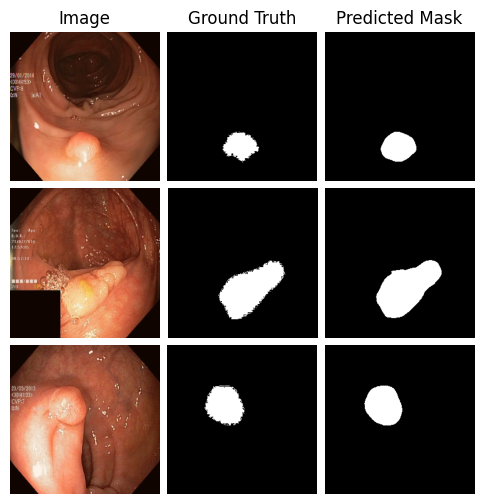

In [ ]:
visualize_prediction_VT(dataset=test1_ds, idx=[10,22,30])

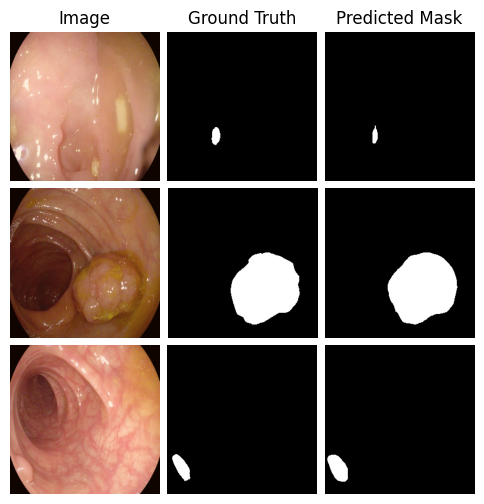

In [ ]:

visualize_prediction_VT(dataset=test2_ds, idx=[12,20,30])

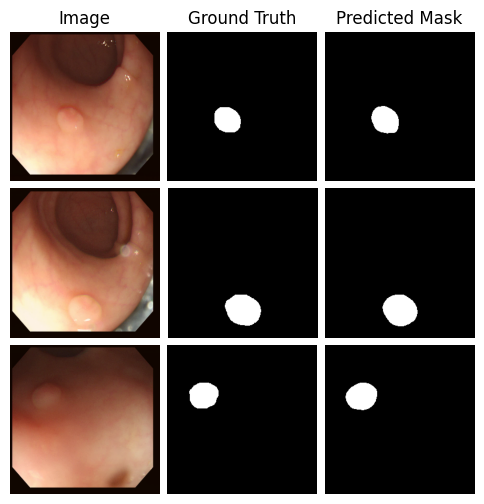

In [ ]:
visualize_prediction_VT(dataset=test3_ds, idx=[10,20,30])

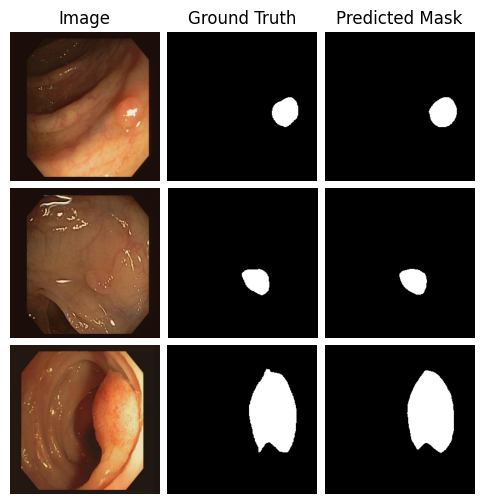

In [ ]:
visualize_prediction_VT(dataset=test4_ds, idx=[10,20,30])

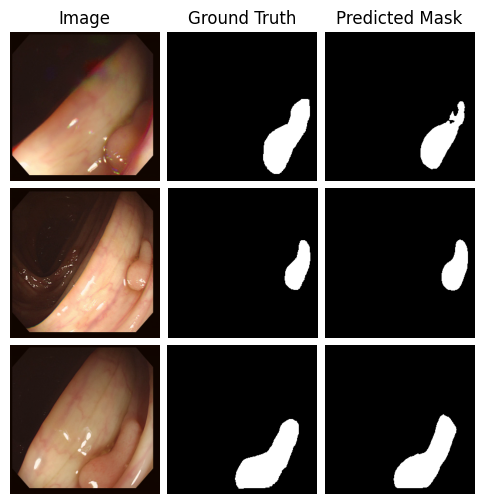

In [ ]:
visualize_prediction_VT(dataset=test5_ds, idx=[10,21,30])